In [2]:
# 유용원의 군사세계 사이트 데이터 크롤링
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.service import Service
from selenium.common.exceptions import WebDriverException
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.chrome.options import Options
import undetected_chromedriver as uc
import time , tempfile 
import sys   
import math   
import pandas as pd   
import os
import random
import urllib.request
import urllib
from openpyxl.styles import Font
from openpyxl import load_workbook
from openpyxl.drawing.image import Image as XLImage
import chromedriver_autoinstaller

print('='*80)
print('< 이 프로그램은 유용원의 군사세계 사이트에서 각종 뉴스 데이터를 수집하는 프로그램 입니다.>')
print('='*80)

q = input('검색하고 싶은 검색어는?(기본값: 우크라이나): ')
if q == '':
    q = '우크라이나'
    
qu = 'https://bemil.chosun.com/nbrd/bbs/list.html?b_bbs_id=10158'
cnt = input('원하시는 수집 건수는 몇건 입니까?(기본값: 20): ')
if cnt == '':
    cnt = 20
    
pcnt = math.ceil(int(cnt) / 15)

now = time.localtime()
s = '%04d-%02d-%02d-%02d-%02d-%02d' %(now.tm_year, now.tm_mon, now.tm_mday, \
                                      now.tm_hour, now.tm_min, now.tm_sec)

ff = 'c:\\py_temp\\'
if ff == '':
    ff = 'c:\\py_temp\\'

img_dir = ff + s + '-' + q + '\\img'

ft_name = ff+s+'-'+q+'\\'+s+'-'+q+'.txt'
fx_name = ff+s+'-'+q+'\\'+s+'-'+q+'.xlsx'
fc_name = ff+s+'-'+q+'\\'+s+'-'+q+'.csv'

chromedriver_autoinstaller.install(path='c:/py_temp')
driver = webdriver.Chrome()

# s = Service("c:/py_temp/chromedriver.exe")
# driver = webdriver.Chrome(service=s)

# 전문가 코너
driver.get(qu)
time.sleep(2)
driver.maximize_window()
time.sleep(2)

# 사이트 전체
cono = input(' 원하시는 코너가 있으습니까?(기본값: 전체) Y or N: ').upper()
if cono == 'Y':
    driver.find_element(By.XPATH,'//*[@id="container-area"]/div[1]/div[2]/div[1]/section/div[2]').click( )
    
    si1 = []
    siteno = 1
    
    html = driver.page_source
    s = BeautifulSoup(html, 'html.parser')
    c1 = s.find('div', 'select-group').find_all('option')
    
    print('선택가능한 사이트는 다음과 같습니다.' + '\n')
    for i in c1:
        si = i.get_text()
        si1.append(si)
        print(str(siteno) + '. ' + si)
        siteno += 1

    print()
    site = input('원하시는 사이트를 입력 하세요(기본값: 전체) 번호로 입력해줘용~~^^: ' + '\n')
    
    if site == '':
        pass
    
    driver.find_element(By.XPATH,'//*[@id="branchid"]/option[%s]' %int(site)).click( )
    time.sleep(1)

else:
    pass

# 내용 찾을때
def scroll_down(driver):      
    driver.execute_script("window.scrollBy(0,600);")
    time.sleep(1)    

# 검색창 찾을때
def scroll_down2(driver):      
    driver.execute_script("window.scrollBy(0,500);")
    time.sleep(1)   

try:
    scroll_down2(driver)
    
    search = driver.find_element(By.XPATH,'//*[@id="container-area"]/div[1]/div[2]/div[1]/section/div[3]/div[3]/span/form/input[1]')
    driver.find_element(By.XPATH,'//*[@id="container-area"]/div[1]/div[2]/div[1]/section/div[3]/div[3]/span/form/input[1]').click( )
    search.send_keys(q)
    search.send_keys('\n')
except:
    scroll_down2(driver)
    
    search = driver.find_element(By.XPATH,'//*[@id="container-area"]/div[1]/div[2]/div[1]/section/div[3]/div[3]/span/form/input[1]')
    driver.find_element(By.XPATH,'//*[@id="container-area"]/div[1]/div[2]/div[1]/section/div[3]/div[3]/span/form/input[1]').click( )
    search.send_keys(q)
    search.send_keys('\n')

no2 = [] # 번호
title2 = [] # 제목
name2 = [] # 작성자
date2 = [] # 작성일
inquiry2 = [] # 조회수
recom2 = [] # 추천수
story2 = [] # 내용
link2 = [] # 페이지 기재된 번호

no = 1
pcno = 1

os.makedirs(img_dir)
os.chdir(img_dir)

stop_all = False

print()
print('데이터를 수집합니다' + '\n')
for w in range(4, 14):
    scroll_down(driver)
    time.sleep(0.5)
    
    html = driver.page_source
    s = BeautifulSoup(html, 'html.parser')
    c1 = s.find('table', 'BasicTables')
    time.sleep(0.5)

    story = []

    c2 = c1.find_all('td')
    for a in c2:
        a1 = a.get_text().strip()
        story.append(a1)
    
    for e in range(0, 15):
        if stop_all:
            break
            
        try:
            try:
                driver.find_element(By.XPATH,'//*[@id="container-area"]/div[1]/div[2]/div[1]/section/div[3]/table/tbody/tr[%s]/td[2]/a' %(e+1)).click( )
                time.sleep(3)
                
            except:
                driver.find_element(By.XPATH,'//*[@id="container-area"]/div[1]/div[2]/div[1]/section/div[3]/table/tbody/tr[%s]/td[2]/a[1]' %(e+1)).click( )
                time.sleep(3)

        except:
            print('자료가 전부입니다ㅠㅠ')
            stop_all = True
            break

        html = driver.page_source
        s = BeautifulSoup(html, 'html.parser')
        c3 = s.find('div', 'board_body').find_all('strong')
        
        try:
            c3[1]
        except:
            try:
                c3 = s.find('div', 'board_body').find_all('div')
                c3[1]
            except:
                c3 = s.find('div', 'board_body').find_all('p')
        
        text = ""
        for c in c3:
            s1 = c.get_text().strip()
            if s1:
                text += s1 + "\n"
        
        # 빈 줄 제거
        clean_text = "\n".join([line for line in text.splitlines() if line.strip() != ""])

        print('-'*80)

        no2.append(str(no) + '\n')
        print('1. 번호: ' + str(no))

        title = c2[1+(e*6)].find('a').get_text()
        title2.append(title)
        print('2. 제목: ' + title)

        name = story[2+(e*6)]
        name2.append(name)
        print('3. 작성자명: ' + name)

        date = story[3+(e*6)]
        date2.append(date)
        print('4. 작성일: ' + date)

        inquiry = story[4+(e*6)]
        inquiry2.append(inquiry + '\n')
        print('5. 조회수: ' + inquiry)

        recom = story[5+(e*6)]
        recom2.append(recom + '\n')
        print('6. 추천수: ' + recom)

        story1 = clean_text
        story2.append(story1)
        print('7. 내용: ' + story1)

        link = 'https://bemil.chosun.com/nbrd/bbs/view.html?b_bbs_id=10158&branch=&pn=%s&num=%s' %(w-3, story[0+(e*6)])
        link2.append(link)
        print('8. 컬럼 링크: ' + link + '\n')

        driver.back()
        time.sleep(3)

        scroll_down(driver)

        no += 1

        if no > int(cnt):
            break
            print('수집을 완료 하였습니다. ^_^')

    if stop_all:
        break

    pcno += 1

    if pcno > pcnt:
        break

    print('다음 페이지로 넘어갑니다~~' + '\n')
    try:
        driver.find_element(By.XPATH,'//*[@id="container-area"]/div[1]/div[2]/div[1]/section/div[3]/div[2]/a[%s]' %w).click( )
        time.sleep(3)

    except:
        break
        print('마지막 페이지 입니다ㅠㅠ')
        

bemil = pd.DataFrame()

bemil['번호'] = no2
bemil['제목'] = pd.Series(title2)
bemil['작성자명'] = pd.Series(name2)
bemil['작성일'] = pd.Series(date2)
bemil['조회수'] = pd.Series(inquiry2)
bemil['추천수'] = pd.Series(recom2)
bemil['내용'] = pd.Series(story2)
bemil['링크'] = pd.Series(link2)

bemil.to_csv(fc_name,encoding="utf-8-sig",index=False)
bemil.to_excel(fx_name ,index=False)

print('='*80)
print('저장을 완료하였습니다.')
print('='*80)

wd = load_workbook(fx_name)
ws = wd["Sheet1"]

ws.column_dimensions['B'].width = 25
row_cnt = int(cnt) + 1

for r in range(2, row_cnt + 1):
    ws.row_dimensions[r].height = 100

for i in range(1, row_cnt):    
    cell_addr = f"B{i+1}"
    img_path = os.path.join(img_dir, f"{i}.jpg")
    if not os.path.exists(img_path):
        continue

    img = XLImage(img_path)
    img.width = 130
    img.height = 100

    ws.add_image(img, cell_addr)

wd.save(fx_name)

wb = load_workbook(fx_name)
ws = wb["Sheet1"]

# 링크 열(예: 8번째 열)에 있는 URL을 하이퍼링크로 변경
for row in range(2, ws.max_row + 1):
    cell = ws.cell(row=row, column=8)  # 8번째 열이 '링크' 열
    url = cell.value
    if isinstance(url, str) and url.startswith("http"):
        cell.hyperlink = url
        cell.style = "Hyperlink"
        cell.font = Font(color="0000EE", underline="single")

# 저장
wb.save(fx_name)
# driver.close()

print('='*80)
print('작업을 완료하였습니다. ^_^')

< 이 프로그램은 유용원의 군사세계 사이트에서 각종 뉴스 데이터를 수집하는 프로그램 입니다.>


검색하고 싶은 검색어는?(기본값: 우크라이나):  
원하시는 수집 건수는 몇건 입니까?(기본값: 20):  30


 원하시는 코너가 있으습니까?(기본값: 전체) Y or N:  n



데이터를 수집합니다

--------------------------------------------------------------------------------
1. 번호: 1
2. 제목: [김형석 칼럼] 알고리즘과 보병, 드론과 포병: 러시아-우크라이나 전쟁이 보여주는 미래 전략
3. 작성자명: 김형석
4. 작성일: 2025.09.30
5. 조회수: 3296
6. 추천수: 1
7. 내용: 알고리즘과 보병, 드론과 포병: 러시아-우크라이나 전쟁이 보여주는 미래 전략
한성대학교 국방과학대학원 국방전력학과 교수 김형석
21세기 전쟁은 더 이상 과거의 공식으로 설명할 수 없는 복합적 양상을 띠고 있다. 러시아-우크라이나 전쟁이 보여주는 가장 핵심적인 변화는 첨단기술과 대량생산, 혁신적 무기체계와 전통적 화력, 자동화 시스템과 인간의 역할이 서로 상충하지 않고 오히려 상호보완적으로 작용한다는 점이다. 이는 미래 군사 전략이 단일한 해답이 아닌 다차원적 접근을 요구함을 의미한다. 2025년 9월 영국 런던에서 열린 국방 및 보안장비국제전시회(Defence and Security Equipment International)에서 NATO 유럽연합군최고사령부 부사령관(Deputy Supreme Allied Commander Europe) 키스 블런트 제독(Admiral Sir Keith Blount)이 제시한 분석은 이러한 복합적 전쟁 양상의 구체적 증거들을 제공한다.
기조연설을 하는 키스 블런트 제독(Admiral Sir Keith Blount)
(https://www.forcesnews.com/news/live-head-newly-formed-cyber-command-speak-tech-top-agenda-dsei-2025)
가장 눈에 띄는 변화는 드론으로 대표되는 무인시스템이 가져온 방법의 혁신이다. 우크라이나의 드론 생산량이 2023년 80만 대에서 2025년 500만 대로 예상되는 것은 단순한 숫자 증가가 아니다.
러시아도 일일 1천 대의 샤헤드-131/13

InvalidSessionIdException: Message: invalid session id: session deleted as the browser has closed the connection
from disconnected: unable to send message to renderer
  (Session info: chrome=143.0.7499.170); For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#invalidsessionidexception
Stacktrace:
Symbols not available. Dumping unresolved backtrace:
	0xde12d3
	0xde1314
	0xbce6dd
	0xbbdf39
	0xbbdeb6
	0xbbc775
	0xbbd456
	0xbca4a9
	0xbdbe5e
	0xbe1976
	0xbbdad2
	0xbdb703
	0xc5da2f
	0xc3b2e6
	0xc0d321
	0xc0e1d4
	0x1035314
	0x10308cb
	0x104d1aa
	0xdfb1d8
	0xe031dd
	0xde95d8
	0xde9799
	0xdd3b28
	0x76a9fcc9
	0x77d782ae
	0x77d7827e


In [9]:
# 유용원의 군사세계 사이트 데이터 크롤링 (WebDriverWait.until(...) "직접" 스타일 버전)
# ✅ time.sleep 최소화 / 요소 뜨면 바로 진행
# ✅ 네가 말한 wait = WebDriverWait(driver, 100) 형태로만 구성

from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.support.ui import WebDriverWait
from selenium.common.exceptions import TimeoutException
import time
import math
import pandas as pd
import os

from openpyxl.styles import Font
from openpyxl import load_workbook
from openpyxl.drawing.image import Image as XLImage
import chromedriver_autoinstaller

print('='*80)
print('< 이 프로그램은 유용원의 군사세계 사이트에서 각종 뉴스 데이터를 수집하는 프로그램 입니다.>')
print('='*80)

# =========================
# 입력
# =========================
q = input('검색하고 싶은 검색어는?(기본값: 우크라이나): ')
if q == '':
    q = '우크라이나'

qu = 'https://bemil.chosun.com/nbrd/bbs/list.html?b_bbs_id=10158'

cnt = input('원하시는 수집 건수는 몇건 입니까?(기본값: 20): ')
if cnt == '':
    cnt = 20
cnt = int(cnt)

pcnt = math.ceil(cnt / 15)

now = time.localtime()
stamp = '%04d-%02d-%02d-%02d-%02d-%02d' %(
    now.tm_year, now.tm_mon, now.tm_mday,
    now.tm_hour, now.tm_min, now.tm_sec
)

ff = 'c:\\py_temp\\'
if ff == '':
    ff = 'c:\\py_temp\\'

base_dir = ff + stamp + '-' + q + '\\'
img_dir  = base_dir + 'img'

fx_name = base_dir + stamp + '-' + q + '.xlsx'
fc_name = base_dir + stamp + '-' + q + '.csv'

os.makedirs(img_dir, exist_ok=True)

# =========================
# 드라이버
# =========================
chromedriver_autoinstaller.install(path='c:/py_temp')

options = webdriver.ChromeOptions()
options.add_argument("--disable-gpu")
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")

driver = webdriver.Chrome(options=options)
driver.set_page_load_timeout(30)

# ✅ 네가 원하는 웨잇 양식
wait = WebDriverWait(driver, 100)

# =========================
# 사이트 접속
# =========================
driver.get(qu)
wait.until(lambda d: d.execute_script("return document.readyState") == "complete")
driver.maximize_window()

# =========================
# 코너 선택
# =========================
cono = input(' 원하시는 코너가 있으습니까?(기본값: 전체) Y or N: ').upper()
if cono == 'Y':
    wait.until(
        EC.element_to_be_clickable((By.XPATH,'//*[@id="container-area"]/div[1]/div[2]/div[1]/section/div[2]'))
    ).click()

    html = driver.page_source
    soup = BeautifulSoup(html, 'html.parser')
    options_list = soup.find('div', 'select-group').find_all('option')

    print('선택가능한 사이트는 다음과 같습니다.\n')
    siteno = 1
    for opt in options_list:
        print(f"{siteno}. {opt.get_text()}")
        siteno += 1

    print()
    site = input('원하시는 사이트를 입력 하세요(기본값: 전체) 번호로 입력해줘용~~^^: \n')
    if site != '':
        wait.until(
            EC.element_to_be_clickable((By.XPATH, f'//*[@id="branchid"]/option[{int(site)}]'))
        ).click()

# 내용 찾을때
def scroll_down(driver):      
    driver.execute_script("window.scrollBy(0,400);")
    time.sleep(1)    

# 검색창 찾을때
def scroll_down2(driver):      
    driver.execute_script("window.scrollBy(0,500);")
    time.sleep(1)   
    
# =========================
# 검색
# =========================
try:
    scroll_down2(driver)
    search_xpath = '//*[@id="container-area"]/div[1]/div[2]/div[1]/section/div[3]/div[3]/span/form/input[1]'
    
    search = wait.until(
        EC.visibility_of_element_located((By.XPATH, search_xpath))
    )
    search.click()
    search.clear()
    search.send_keys(q)
    search.send_keys(Keys.ENTER)
except:
    scroll_down2(driver)
    search_xpath = '//*[@id="container-area"]/div[1]/div[2]/div[1]/section/div[3]/div[3]/span/form/input[1]'
    
    search = wait.until(
        EC.visibility_of_element_located((By.XPATH, search_xpath))
    )
    search.click()
    search.clear()
    search.send_keys(q)
    search.send_keys(Keys.ENTER)

# 검색 결과 테이블 뜰 때까지
wait.until(
    EC.presence_of_element_located((By.XPATH, '//*[@id="container-area"]/div[1]/div[2]/div[1]/section/div[3]/table'))
)

# =========================
# 결과 저장 리스트
# =========================
no2, title2, name2, date2, inquiry2, recom2, story2, link2 = ([] for _ in range(8))

no = 1
pcno = 1
stop_all = False

print()
print('데이터를 수집합니다\n')

# =========================
# 크롤링 루프
# =========================
for w in range(4, 14):
    if stop_all:
        break

    # 테이블 로드 대기
    wait.until(EC.presence_of_element_located((By.CLASS_NAME, "BasicTables")))

    html = driver.page_source
    soup = BeautifulSoup(html, 'html.parser')
    c1 = soup.find('table', 'BasicTables')
    if c1 is None:
        print("테이블을 찾지 못했습니다. 사이트 구조가 바뀌었을 수 있어요.")
        break

    story = []
    c2 = c1.find_all('td')
    for a in c2:
        story.append(a.get_text().strip())

    for e in range(0, 15):
        if no > cnt:
            stop_all = True
            break

        # 게시글 클릭 (두 형태 시도)
        row_xpath_1 = f'//*[@id="container-area"]/div[1]/div[2]/div[1]/section/div[3]/table/tbody/tr[{e+1}]/td[2]/a'
        row_xpath_2 = f'//*[@id="container-area"]/div[1]/div[2]/div[1]/section/div[3]/table/tbody/tr[{e+1}]/td[2]/a[1]'

        clicked = False

        # 최대 3번 시도: (클릭 → 스크롤 → 클릭 → 스크롤 → 클릭)
        for _ in range(3):
            try:
                try:
                    wait.until(
                        EC.element_to_be_clickable((By.XPATH, row_xpath_1))
                    ).click()
                except:
                    wait.until(
                        EC.element_to_be_clickable((By.XPATH, row_xpath_2))
                    ).click()
        
                # ✅ 본문이 뜨는 즉시 진행
                wait.until(
                    EC.presence_of_element_located((By.CLASS_NAME, "board_body"))
                )
                wait.until(
                    lambda d: d.execute_script("return document.readyState") == "complete"
                )
        
                clicked = True
                break  # 성공했으니 루프 탈출
        
            except:
                # 클릭 실패 → 스크롤 후 재시도
                scroll_down(driver)
        
        # 3번 다 실패 → 자료 자체가 없음 → 전체 종료
        if not clicked:
            print('자료가 전부입니다ㅠㅠ')
            stop_all = True
            break


        # 본문 파싱
        html = driver.page_source
        soup = BeautifulSoup(html, 'html.parser')

        board = soup.find('div', 'board_body')
        blocks = []
        if board:
            blocks = board.find_all('strong')
            if len(blocks) < 2:
                blocks = board.find_all('div')
            if len(blocks) < 2:
                blocks = board.find_all('p')

        text = ""
        for c in blocks:
            s1 = c.get_text().strip()
            if s1:
                text += s1 + "\n"

        clean_text = "\n".join([line for line in text.splitlines() if line.strip() != ""])

        print('-'*80)

        no2.append(str(no) + '\n')
        print('1. 번호: ' + str(no))

        # 제목/작성자/날짜/조회/추천
        try:
            title = c2[1+(e*6)].find('a').get_text()
        except:
            title = ""
        title2.append(title)
        print('2. 제목: ' + title)

        name = story[2+(e*6)] if len(story) > 2+(e*6) else ""
        name2.append(name)
        print('3. 작성자명: ' + name)

        date = story[3+(e*6)] if len(story) > 3+(e*6) else ""
        date2.append(date)
        print('4. 작성일: ' + date)

        inquiry = story[4+(e*6)] if len(story) > 4+(e*6) else ""
        inquiry2.append(inquiry + '\n')
        print('5. 조회수: ' + inquiry)

        recom = story[5+(e*6)] if len(story) > 5+(e*6) else ""
        recom2.append(recom + '\n')
        print('6. 추천수: ' + recom)

        story2.append(clean_text)
        print('7. 내용: ' + clean_text)

        # 링크 생성(원 코드 유지)
        num_val = story[0+(e*6)] if len(story) > 0+(e*6) else ""
        link = f'https://bemil.chosun.com/nbrd/bbs/view.html?b_bbs_id=10158&branch=&pn={w-3}&num={num_val}'
        link2.append(link)
        print('8. 컬럼 링크: ' + link + '\n')

        # 뒤로가기 후 리스트 테이블 복귀 대기
        driver.back()
        wait.until(lambda d: d.execute_script("return document.readyState") == "complete")
        wait.until(EC.presence_of_element_located((By.CLASS_NAME, "BasicTables")))

        no += 1

    if stop_all:
        break

    pcno += 1
    if pcno > pcnt:
        break

    print('다음 페이지로 넘어갑니다~~\n')

    next_page_xpath = f'//*[@id="container-area"]/div[1]/div[2]/div[1]/section/div[3]/div[2]/a[{w}]'
    
    page_moved = False
    
    # 최대 3번 시도: 클릭 → 스크롤 → 클릭 → 스크롤 → 클릭
    for _ in range(3):
        try:
            wait.until(
                EC.element_to_be_clickable((By.XPATH, next_page_xpath))
            ).click()
    
            # 페이지 로드 대기
            wait.until(
                lambda d: d.execute_script("return document.readyState") == "complete"
            )
            wait.until(
                EC.presence_of_element_located((By.CLASS_NAME, "BasicTables"))
            )
    
            page_moved = True
            break
    
        except:
            # 클릭 실패 → 스크롤 후 재시도
            scroll_down(driver)
    
    # 3번 다 실패 → 마지막 페이지
    if not page_moved:
        print('마지막 페이지 입니다ㅠㅠ')
        break


# =========================
# 저장
# =========================
bemil = pd.DataFrame({
    "번호": no2,
    "제목": pd.Series(title2),
    "작성자명": pd.Series(name2),
    "작성일": pd.Series(date2),
    "조회수": pd.Series(inquiry2),
    "추천수": pd.Series(recom2),
    "내용": pd.Series(story2),
    "링크": pd.Series(link2),
})

bemil.to_csv(fc_name, encoding="utf-8-sig", index=False)
bemil.to_excel(fx_name, index=False)

print('='*80)
print('저장을 완료하였습니다.')
print('='*80)

# =========================
# 엑셀 하이퍼링크
# =========================
wb = load_workbook(fx_name)
ws = wb["Sheet1"]

for row in range(2, ws.max_row + 1):
    cell = ws.cell(row=row, column=8)  # 8번째 열이 '링크'
    url = cell.value
    if isinstance(url, str) and url.startswith("http"):
        cell.hyperlink = url
        cell.style = "Hyperlink"
        cell.font = Font(color="0000EE", underline="single")

wb.save(fx_name)

# driver.close()
print('='*80)
print('작업을 완료하였습니다. ^_^')
print('='*80)


< 이 프로그램은 유용원의 군사세계 사이트에서 각종 뉴스 데이터를 수집하는 프로그램 입니다.>


검색하고 싶은 검색어는?(기본값: 우크라이나):  
원하시는 수집 건수는 몇건 입니까?(기본값: 20):  30
 원하시는 코너가 있으습니까?(기본값: 전체) Y or N:  n



데이터를 수집합니다

--------------------------------------------------------------------------------
1. 번호: 1
2. 제목: [김형석 칼럼] 알고리즘과 보병, 드론과 포병: 러시아-우크라이나 전쟁이 보여주는 미래 전략
3. 작성자명: 김형석
4. 작성일: 2025.09.30
5. 조회수: 3301
6. 추천수: 1
7. 내용: 알고리즘과 보병, 드론과 포병: 러시아-우크라이나 전쟁이 보여주는 미래 전략
한성대학교 국방과학대학원 국방전력학과 교수 김형석
21세기 전쟁은 더 이상 과거의 공식으로 설명할 수 없는 복합적 양상을 띠고 있다. 러시아-우크라이나 전쟁이 보여주는 가장 핵심적인 변화는 첨단기술과 대량생산, 혁신적 무기체계와 전통적 화력, 자동화 시스템과 인간의 역할이 서로 상충하지 않고 오히려 상호보완적으로 작용한다는 점이다. 이는 미래 군사 전략이 단일한 해답이 아닌 다차원적 접근을 요구함을 의미한다. 2025년 9월 영국 런던에서 열린 국방 및 보안장비국제전시회(Defence and Security Equipment International)에서 NATO 유럽연합군최고사령부 부사령관(Deputy Supreme Allied Commander Europe) 키스 블런트 제독(Admiral Sir Keith Blount)이 제시한 분석은 이러한 복합적 전쟁 양상의 구체적 증거들을 제공한다.
기조연설을 하는 키스 블런트 제독(Admiral Sir Keith Blount)
(https://www.forcesnews.com/news/live-head-newly-formed-cyber-command-speak-tech-top-agenda-dsei-2025)
가장 눈에 띄는 변화는 드론으로 대표되는 무인시스템이 가져온 방법의 혁신이다. 우크라이나의 드론 생산량이 2023년 80만 대에서 2025년 500만 대로 예상되는 것은 단순한 숫자 증가가 아니다.
러시아도 일일 1천 대의 샤헤드-131/13

In [1]:
from konlpy.tag import *        #pip install konlpy 먼저 하세요
import matplotlib.pyplot as plt #pip install matplotlib 먼저 하세요
from matplotlib import font_manager , rc
from wordcloud import WordCloud  # pip install wordcloud 먼저 하세요
from collections import Counter
from PIL import Image      # pip install Image
from wordcloud import ImageColorGenerator
import nltk
from nltk.probability import FreqDist

In [5]:
data = pd.read_excel('C:\\py_temp\\2025-12-31-12-00-17-우크라이나\\2025-12-31-12-00-17-우크라이나.xlsx')
data1 = data[data['작성일'] >= '2023.02.23']['내용']
data1

okt = Okt()
kkma = Kkma( )

data3 = []
for a in range(0, len(data1)):
    data2 = okt.nouns(data1[a])
    for i in range(0, len(data2)):
        data3.append(data2[i])


Counter({'우크라이나': 509, '드론': 489, '러시아': 468, '전쟁': 278, '북한': 223, '체계': 189, '기술': 163, '시스템': 159, '전략': 152, '작전': 150, '대한': 141, '군사': 136, '능력': 128, '공격': 118, '중국': 116, '대응': 108, '전장': 107, '미국': 106, '지원': 104, '효과': 99, '운용': 98, '전자전': 95, '정보': 94, '방어': 85, '개발': 83, '경제': 82, '지역': 82, '지휘': 81, '한국': 80, '제공': 78, '전투': 77, '활용': 77, '국제': 76, '통해': 76, '방공': 76, '러시아군': 76, '변화': 74, '통합': 73, '대전': 73, '혁신': 70, '무기': 66, '발전': 66, '전술': 65, '핵심': 62, '국가': 61, '환경': 58, '정찰': 58, '현대': 57, '위협': 57, '부대': 57, '상황': 56, '타격': 56, '쿠르스크': 54, '수행': 53, '협력': 52, '문제': 51, '배치': 50, '위치': 50, '사례': 49, '비용': 49, '미사일': 49, '구축': 49, '교훈': 49, '영향': 49, '사용': 48, '분석': 44, '경험': 44, '내전': 44, '스페인': 44, '생산': 43, '지속': 43, '미래': 42, '안보': 42, '현재': 42, '병력': 42, '기반': 41, '주요': 41, '시민': 41, '중국군': 41, '정밀': 40, '전선': 40, '평가': 40, '확보': 39, '가능성': 39, '무기체계': 38, '제재': 38, '참여': 37, '첨단': 36, '한반도': 36, '통신': 36, '복합': 35, '역할': 35, '요소': 35, '양상': 34, '장비': 34, '직접':

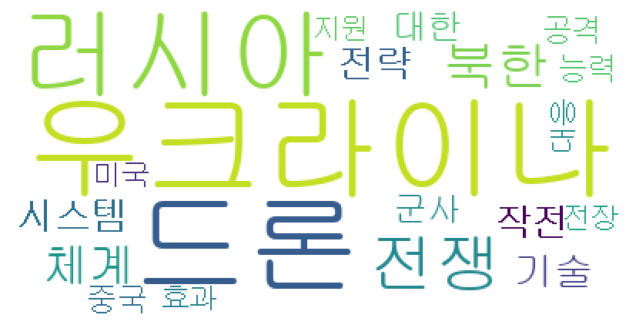

In [6]:
sword = open("c:\\py_temp\\불용어목록.txt", encoding = 'utf-8').read()

data4 = [ each_word for each_word in data3
          if each_word not in sword ]

data5 = Counter(data4)
print(data5)
data6 = data5.most_common(20)
data7 = dict(data6)
data7

wordcloud = WordCloud(font_path="c:\\windows\\fonts\\gulim.TTc" ,
                       relative_scaling=0.9,
                       background_color="white"
                     ).generate_from_frequencies(data7)
plt.figure(figsize=(8,4))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()